# Goalkeeper model first attempt

First attempt at buidling a goalkeeper model. This is more intended to review the state of the data I have, what more data I might need, so I can inform other data extraction requirements.

## Checklist for notebook
- [x] Filter data to just goalkeepers
- [x] Understand if there's season bias (do points differ greatly between seasons)
- [x] Look at any big outliers
- [x] Work out the data you'd like to add to goalkeepers to help predictions
- [ ] Create a GK experiment in mlflow and train a simple model on initial data 

In [1]:
from matplotlib import pyplot as plt
import mlflow
import polars as pl
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from fantasy_football.constants import DATA_FOLDER, MODELS_FOLDER, MLFLOW_DB_PATH
from fantasy_football.processors.team_features import merge_team_conceded, merge_team_saves, merge_team_scored
from fantasy_football.processors.player_features import merge_player_conceded, get_player_rolling_minutes
from fantasy_football.processors.gk_features import merge_gk_rolling_saves
from fantasy_football.models.evaluation import PlayerModelMetrics
from fantasy_football.models.utils import save_model, save_pipeline

In [2]:
player_data_filepath = DATA_FOLDER.joinpath("raw","cleaned_merged_seasons.csv")
player_data = pl.read_csv(player_data_filepath, try_parse_dates=True).sort("kickoff_time")

player_data.head()

season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
str,str,str,str,i64,i64,i64,i64,f64,i64,i64,i64,i64,f64,f64,"datetime[μs, UTC]",i64,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,bool,i64,i64
"""2016-17""","""Andrew Robertson""","""DEF""",null,0,0,14,0,1.8,152,4,1,0,1.7,14.8,2016-08-13 11:30:00 UTC,90,8,"""Leicester""",0,0,0,0,1,0,32036,1.0,2.0,0.0,2,0,0,0,45,true,0,1
"""2016-17""","""Benjamin Chilwell""","""DEF""",null,0,0,0,0,0.0,496,4,0,0,0.0,0.0,2016-08-13 11:30:00 UTC,0,7,"""Hull""",0,0,0,0,1,0,8192,1.0,2.0,0.0,0,0,0,0,45,false,0,1
"""2016-17""","""Christian Fuchs""","""DEF""",null,0,0,17,0,13.8,168,4,2,0,5.6,25.4,2016-08-13 11:30:00 UTC,90,7,"""Hull""",0,0,0,0,1,0,418306,1.0,2.0,17.0,0,0,0,0,55,false,1,1
"""2016-17""","""Daniel Amartey""","""DEF""",null,0,0,6,0,10.5,182,4,0,0,1.9,8.0,2016-08-13 11:30:00 UTC,23,7,"""Hull""",0,0,0,0,1,0,2315,1.0,2.0,0.0,1,0,0,0,45,false,0,1
"""2016-17""","""Demarai Gray""","""MID""",null,1,0,16,0,2.9,181,4,2,0,2.2,1.6,2016-08-13 11:30:00 UTC,67,7,"""Hull""",0,0,0,0,1,0,19681,1.0,2.0,17.0,5,0,0,0,50,false,0,1


In [3]:
player_data["position"].unique()

position
str
"""GKP"""
"""DEF"""
"""FWD"""
"""MID"""
"""GK"""


In [4]:
gk_positions = ["GK", "GKP"]

gk_data = player_data.filter(pl.col("position").is_in(gk_positions))
gk_data.head()

season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
str,str,str,str,i64,i64,i64,i64,f64,i64,i64,i64,i64,f64,f64,"datetime[μs, UTC]",i64,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,bool,i64,i64
"""2016-17""","""Eldin Jakupovic""","""GK""",null,0,0,16,0,0.0,147,4,1,0,2.5,25.2,2016-08-13 11:30:00 UTC,90,8,"""Leicester""",0,0,0,0,1,4,451193,1.0,2.0,0.0,3,0,0,0,40,true,0,1
"""2016-17""","""Kasper Schmeichel""","""GK""",null,0,0,14,0,0.0,165,4,2,0,2.5,24.6,2016-08-13 11:30:00 UTC,90,7,"""Hull""",0,0,0,0,1,3,448030,1.0,2.0,0.0,2,0,0,0,50,false,0,1
"""2016-17""","""Alex McCarthy""","""GK""",null,0,0,0,0,0.0,101,7,0,0,0.0,0.0,2016-08-13 14:00:00 UTC,0,18,"""Watford""",0,0,0,0,1,0,8821,1.0,1.0,0.0,0,0,0,0,45,true,0,1
"""2016-17""","""Ben Foster""","""GK""",null,0,3,32,1,10.0,430,2,0,0,3.4,23.6,2016-08-13 14:00:00 UTC,90,5,"""Crystal Palace""",0,0,0,0,1,4,173290,1.0,0.0,0.0,10,0,0,0,45,false,0,1
"""2016-17""","""Fraser Forster""","""GK""",null,0,0,7,0,0.0,294,7,1,0,0.2,2.0,2016-08-13 14:00:00 UTC,90,18,"""Watford""",0,0,0,0,1,0,171065,1.0,1.0,0.0,2,0,0,0,50,true,0,1


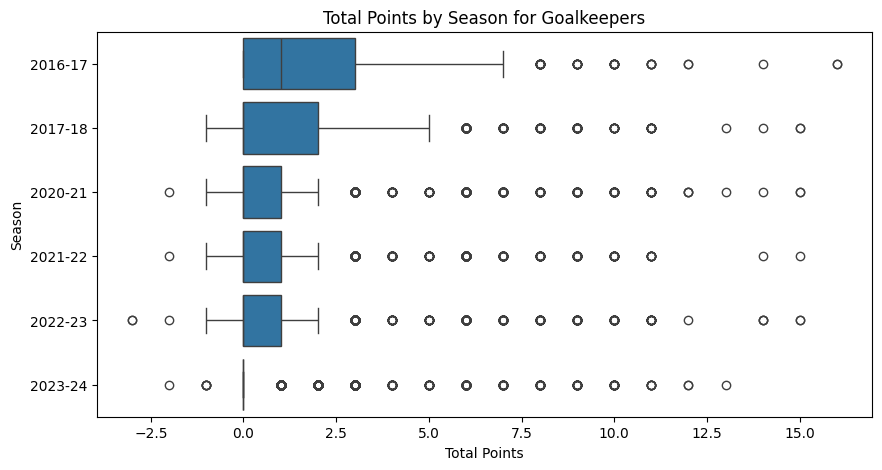

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=gk_data, y="season_x", x="total_points", ax=ax)

ax.set(
    xlabel="Total Points",
    ylabel="Season",
    title="Total Points by Season for Goalkeepers"
)

plt.show()



In [6]:
# wishlist 
# - minutes
# - team conceded data
# - fixture difficulty (ELO)
# - oppositon attacking strength
# - team shots conceced
# - team penalties conceded
# - card data 
# XG against 
# - opposition xG
# - errors leading to goals


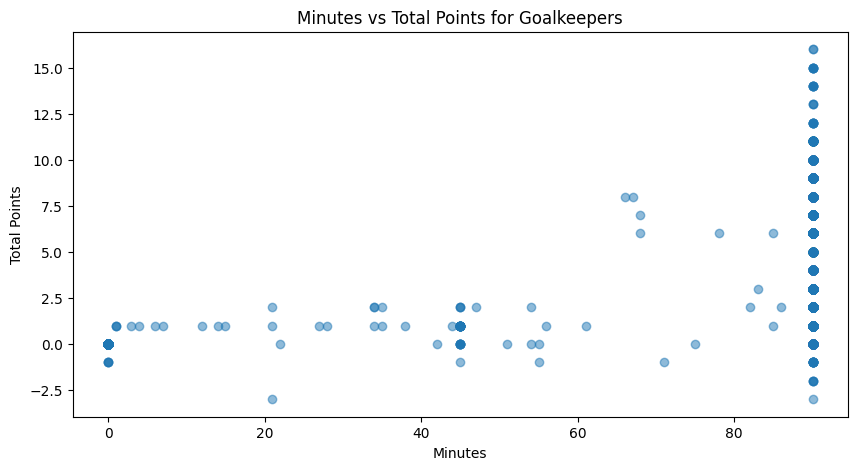

In [7]:
# minutes
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(gk_data["minutes"], gk_data["total_points"], alpha=0.5)

ax.set(
    xlabel="Minutes",
    ylabel="Total Points",
    title="Minutes vs Total Points for Goalkeepers"
)

plt.show()

In [8]:
# both ridiculous performances with penalty saves 
gk_data.filter(pl.col("total_points") > 15)

season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
str,str,str,str,i64,i64,i64,i64,f64,i64,i64,i64,i64,f64,f64,"datetime[μs, UTC]",i64,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,bool,i64,i64
"""2016-17""","""Fraser Forster""","""GK""",null,0,3,54,1,0.0,294,357,0,0,6.6,65.6,2017-05-07 12:30:00 UTC,90,9,"""Liverpool""",0,0,1,0,36,8,198164,0.0,0.0,0.0,16,10310,15105,4795,50,false,0,36
"""2016-17""","""Sergio Romero""","""GK""",null,0,3,51,1,0.0,243,279,0,0,5.5,55.4,2017-05-17 18:45:00 UTC,90,13,"""Southampton""",0,0,1,0,37,6,6288,0.0,0.0,0.0,16,-33,30,63,47,false,0,37


In [9]:
gk_data.filter((pl.col("name") == "David de Gea") & (pl.col("season_x") == "2016-17")).head()

season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
str,str,str,str,i64,i64,i64,i64,f64,i64,i64,i64,i64,f64,f64,"datetime[μs, UTC]",i64,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,bool,i64,i64
"""2016-17""","""David de Gea""","""GK""",null,0,0,10,0,0.0,242,9,1,0,1.7,17.2,2016-08-14 12:30:00 UTC,90,2,"""Bournemouth""",0,0,0,0,1,2,1392043,3.0,1.0,0.0,2,0,0,0,55,false,0,1
"""2016-17""","""David de Gea""","""GK""",null,0,0,21,1,0.0,242,11,0,0,0.8,8.4,2016-08-19 19:00:00 UTC,90,13,"""Southampton""",0,0,0,0,2,1,1599510,0.0,2.0,0.0,6,20807,48379,27572,55,true,0,2
"""2016-17""","""David de Gea""","""GK""",null,0,0,23,1,0.0,242,24,0,0,1.7,17.2,2016-08-27 16:30:00 UTC,90,7,"""Hull""",0,0,0,0,3,2,1703167,1.0,0.0,0.0,6,8827,47432,38605,55,false,0,3
"""2016-17""","""David de Gea""","""GK""",null,0,0,17,0,0.0,242,35,2,0,3.5,35.0,2016-09-10 11:30:00 UTC,90,10,"""Man City""",0,0,0,0,4,4,1750983,2.0,1.0,0.0,2,-14166,39801,53967,55,true,0,4
"""2016-17""","""David de Gea""","""GK""",null,0,0,10,0,0.0,242,50,3,0,1.0,9.8,2016-09-18 11:00:00 UTC,90,18,"""Watford""",0,0,0,0,5,2,1770015,1.0,3.0,0.0,1,-8058,19085,27143,55,false,0,5


In [10]:
gk_data.filter((pl.col("name") == "David de Gea") & (pl.col("season_x") == "2017-18")).head()

season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
str,str,str,str,i64,i64,i64,i64,f64,i64,i64,i64,i64,f64,f64,"datetime[μs, UTC]",i64,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,bool,i64,i64
"""2017-18""","""David de Gea""","""GK""",null,0,0,22,1,0.0,260,9,0,0,1.1,10.6,2017-08-13 15:00:00 UTC,90,20,"""West Ham""",0,0,0,0,1,1,1195182,0.0,4.0,0.0,6,0,0,0,55,true,0,1
"""2017-18""","""David de Gea""","""GK""",null,0,0,22,1,0.0,260,17,0,0,0.6,5.6,2017-08-19 11:30:00 UTC,90,16,"""Swansea""",0,0,0,0,2,1,1495257,4.0,0.0,0.0,6,34341,59890,25549,55,false,0,2
"""2017-18""","""David de Gea""","""GK""",null,0,0,29,1,0.0,260,25,0,0,2.7,27.0,2017-08-26 16:30:00 UTC,90,9,"""Leicester""",0,0,0,0,3,4,1577700,0.0,2.0,0.0,7,-16794,47672,64466,55,true,0,3
"""2017-18""","""David de Gea""","""GK""",null,0,0,14,0,0.0,260,37,2,0,1.8,17.8,2017-09-09 16:30:00 UTC,90,15,"""Stoke""",0,0,0,0,4,3,1689047,2.0,2.0,0.0,2,17780,65416,47636,55,false,0,4
"""2017-18""","""David de Gea""","""GK""",null,0,0,25,1,0.0,260,50,0,0,2.3,22.6,2017-09-17 15:00:00 UTC,90,7,"""Everton""",0,0,0,0,5,3,1744231,0.0,4.0,0.0,7,9510,47149,37639,55,true,0,5


In [11]:
gk_data = merge_player_conceded(gk_data)
gk_data.filter(pl.col("name") == "Đorđe Petrović").tail()

season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,goals_conceded_right,player_conceded_rolling_5,player_minutes_rolling_5
str,str,str,str,i64,i64,i64,i64,f64,i64,i64,i64,i64,f64,f64,"datetime[μs, UTC]",i64,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,bool,i64,i64,i64,f64,i64
"""2023-24""","""Đorđe Petrović""","""GK""","""Chelsea""",0,2,28,1,0.0,687,255,0,0,2.6,25.8,2024-05-02 18:30:00 UTC,90,18,"""Spurs""",0,0,0,0,35,4,514605,0.0,2.0,0.0,9,232272,264125,31853,46,true,0,35,0,2.4,450
"""2023-24""","""Đorđe Petrović""","""GK""","""Chelsea""",0,0,31,1,0.0,687,355,0,0,1.3,13.4,2024-05-05 13:00:00 UTC,90,19,"""West Ham""",0,0,0,0,36,2,593526,0.0,5.0,0.0,6,82945,92078,9133,46,true,0,36,0,1.8,450
"""2023-24""","""Đorđe Petrović""","""GK""","""Chelsea""",0,0,12,0,0.0,687,367,2,0,1.8,17.8,2024-05-11 16:30:00 UTC,90,16,"""Nott'm Forest""",0,0,0,0,37,2,936843,3.0,2.0,0.0,1,298263,309808,11545,47,false,0,37,2,1.4,450
"""2023-24""","""Đorđe Petrović""","""GK""","""Chelsea""",0,0,14,0,0.0,687,332,1,0,1.0,10.4,2024-05-15 18:45:00 UTC,90,5,"""Brighton""",0,0,0,0,37,1,936843,2.0,1.0,0.0,2,298263,309808,11545,47,false,0,37,1,1.8,450
"""2023-24""","""Đorđe Petrović""","""GK""","""Chelsea""",0,0,18,0,0.0,687,375,1,0,3.8,38.4,2024-05-19 15:00:00 UTC,90,3,"""Bournemouth""",0,0,0,0,38,5,911462,1.0,2.0,0.0,3,22145,46910,24765,47,true,0,38,1,1.0,450


In [12]:
test = gk_data.select(["name", "kickoff_time", "team_x", "minutes", "goals_conceded", "saves", "opp_team_name", "total_points"])
test = merge_team_conceded(test)
test = merge_player_conceded(test)
test = get_player_rolling_minutes(test)
test = merge_gk_rolling_saves(test)
test = merge_team_saves(test)
test = merge_team_scored(test, by_left="opp_team_name")
test = test.rename({"team_scored_rolling_5": "opponent_team_scored_rolling_5"})
test.filter((pl.col("name") == "Đorđe Petrović")).tail(10)

name,kickoff_time,team_x,minutes,goals_conceded,saves,opp_team_name,total_points,team_goals_conceded,team_conceded_rolling_5,goals_conceded_right,player_conceded_rolling_5,player_minutes_rolling_5,gk_saves_rolling_5,gk_minutes_rolling_5,gk_saves_per_90_rolling_5,team_saves,team_saves_rolling_5,team_goals_scored,opponent_team_scored_rolling_5
str,"datetime[μs, UTC]",str,i64,i64,i64,str,i64,i64,f64,i64,f64,f64,i64,i64,f64,i64,f64,i64,f64
"""Đorđe Petrović""",2024-04-04 19:15:00 UTC,"""Chelsea""",90,3,2,"""Man Utd""",1,3,1.6,3,1.6,90.0,15,450,3.0,2,3.0,3,1.4
"""Đorđe Petrović""",2024-04-07 16:30:00 UTC,"""Chelsea""",90,2,3,"""Sheffield Utd""",2,2,2.0,2,2.0,90.0,14,450,2.8,3,2.8,2,1.2
"""Đorđe Petrović""",2024-04-15 19:00:00 UTC,"""Chelsea""",90,0,2,"""Everton""",6,0,2.2,0,2.2,90.0,13,450,2.6,2,2.6,0,0.8
"""Đorđe Petrović""",2024-04-23 19:00:00 UTC,"""Chelsea""",90,5,6,"""Arsenal""",2,5,1.8,5,1.8,90.0,12,450,2.4,6,2.4,5,1.4
"""Đorđe Petrović""",2024-04-27 19:00:00 UTC,"""Chelsea""",90,2,3,"""Aston Villa""",2,2,2.4,2,2.4,90.0,17,450,3.4,3,3.4,2,2.2
"""Đorđe Petrović""",2024-05-02 18:30:00 UTC,"""Chelsea""",90,0,4,"""Spurs""",9,0,2.4,0,2.4,90.0,16,450,3.2,4,3.2,0,1.6
"""Đorđe Petrović""",2024-05-05 13:00:00 UTC,"""Chelsea""",90,0,2,"""West Ham""",6,0,1.8,0,1.8,90.0,18,450,3.6,2,3.6,0,1.4
"""Đorđe Petrović""",2024-05-11 16:30:00 UTC,"""Chelsea""",90,2,2,"""Nott'm Forest""",1,2,1.4,2,1.4,90.0,17,450,3.4,2,3.4,2,1.8
"""Đorđe Petrović""",2024-05-15 18:45:00 UTC,"""Chelsea""",90,1,1,"""Brighton""",2,1,1.8,1,1.8,90.0,17,450,3.4,1,3.4,1,0.6


In [13]:
test = test.filter(pl.col("team_x").is_not_null())

In [ ]:
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")
mlflow.set_experiment("goalkeeper_model")

with mlflow.start_run() as run:
    cols_to_drop = [
        "name",
        "kickoff_time",
        "team_x",
        "minutes",
        "goals_conceded",
        "saves",
        "opp_team_name",
        "total_points",
        "team_goals_conceded",
        "goals_conceded_right"
        "team_saves",
        "team_goals_scored"
    ]

    x = test.drop(cols_to_drop)
    features = x.columns
    y = test.select(["total_points"])

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    numerical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    numerical_pipeline.fit(x_train)
    x_train = numerical_pipeline.transform(x_train)
    x_test = numerical_pipeline.transform(x_test)

    numerical_pipeline_path = MODELS_FOLDER.joinpath("gk_numerical_pipeline.pkl")
    save_pipeline(numerical_pipeline, numerical_pipeline_path)
    
    model = LinearRegression()
    model.fit(x_train, y_train)

    model_path = MODELS_FOLDER.joinpath("gk_linear_regression.pkl")
    save_model(model, model_path)

    y_pred = model.predict(x_test)

    metrics = PlayerModelMetrics(y_test, y_pred)
    metrics.metrics_report()

    mlflow.log_params(model.get_params())
    mlflow.log_params({"features": features})
    mlflow.log_metrics(metrics.metrics_report())
    mlflow.log_artifact(str(numerical_pipeline_path))
    mlflow.sklearn.log_model(
        sk_model=model,  # Your trained model object
        artifact_path="model",  # Path within the MLflow run's artifact store
        registered_model_name="goalkeeper_linear_regression"  # Optional: register in model registry
    )
